# Heat Conduction in a Slab, a Cylinder and a Sphere

**Prepared by:** Prof. Alexander Dowling (2026)

This notebook is the PDE companion to Lecture 7. We take one transient conduction problem,
write it for three geometries at once, discretize space with the **method of lines**, and solve
the resulting differential-algebraic system with `Pyomo.dae`.

The physical problem and the idea of indexing the three geometries with a single shape parameter
are adapted from J. C. Kantor,
[*ND Pyomo Cookbook*](https://jckantor.github.io/ND-Pyomo-Cookbook/),
notebook 5.03 "Heat Conduction in Various Geometries". The derivation, the code and the numerical
experiments below are our own.

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 33 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
# Install Pyomo and solvers for Google Colab
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae
from pyomo.util.model_size import build_model_size_report
from scipy.special import j0, j1, jn_zeros

## Learning Objectives

* Nondimensionalize a transient conduction PDE and recognize the **Fourier number** as its only time scale
* Write **one** model that covers a slab, a cylinder and a sphere through a shape index $s$
* Apply the **method of lines**: discretize space first, then hand a DAE in time to `Pyomo.dae`
* Compare **finite difference**, **finite volume** and **finite element** spatial discretizations, and say where each belongs
* Handle the $r = 0$ **coordinate singularity** correctly
* Run the **IDAES Diagnostics Toolbox** on a `Pyomo.dae` model and read its report -- including the
  difference between a warning and a caution
* Recognize a **dangling variable**: a derivative that appears in no discretization equation, which IPOPT
  will happily declare `optimal`

## The Physical Problem

A solid body, initially at uniform temperature $T_0$, is dropped at $t=0$ into a bath held at
$T_\infty$. The surface reaches the bath temperature immediately, and we want the temperature
everywhere inside as a function of time.

With constant thermal conductivity $k$, density $\rho$ and heat capacity $C_p$, and no source term,
the energy balance is

$$\rho C_p \frac{\partial T}{\partial t} = \nabla \cdot \left( k \nabla T \right) = k \nabla^2 T .$$

Divide by $\rho C_p$ and define the **thermal diffusivity** $\alpha = k / (\rho C_p)$, which has units
of length$^2$/time:

$$\frac{\partial T}{\partial t} = \alpha \nabla^2 T .$$

### One Equation, Three Geometries

The three classical bodies -- an infinite slab of half-thickness $R$, an infinite cylinder of
radius $R$, and a sphere of radius $R$ -- are all *one-dimensional*: temperature depends on a single
space coordinate $r$ measured from the center. In each case the Laplacian of a radially symmetric
field is

$$\nabla^2 T = \frac{1}{r^{s}} \frac{\partial}{\partial r}\left( r^{s} \frac{\partial T}{\partial r} \right)
            = \frac{\partial^2 T}{\partial r^2} + \frac{s}{r} \frac{\partial T}{\partial r},$$

where the **shape index** $s$ is

| Geometry | $s$ | $r$ measured from | Surface at |
| :-- | :-: | :-- | :-- |
| Slab (infinite plate, half-thickness $R$) | 0 | the midplane | $r = R$ |
| Cylinder (infinite, radius $R$) | 1 | the axis | $r = R$ |
| Sphere (radius $R$) | 2 | the center | $r = R$ |

For the slab, $s=0$ and the extra term vanishes -- Cartesian coordinates. For $s = 1$ and $s = 2$
the geometry contributes the $\tfrac{s}{r}\partial T/\partial r$ term, which is **singular at the
center**. That singularity is the interesting part of this notebook, so hold onto it.

### Nondimensionalization

Three scales are available: the temperature difference the body must cross, the body's own size, and
the time the heat needs to cross it. Define

$$T' = \frac{T - T_0}{T_\infty - T_0}, \qquad
  r' = \frac{r}{R}, \qquad
  t' = \frac{\alpha t}{R^2}.$$

Substituting, with $T = T_0 + (T_\infty - T_0) T'$, $r = R r'$ and $t = R^2 t' / \alpha$:

$$\frac{\partial T}{\partial t} = \frac{(T_\infty - T_0)\,\alpha}{R^2} \frac{\partial T'}{\partial t'},
\qquad
\frac{\partial^2 T}{\partial r^2} = \frac{T_\infty - T_0}{R^2} \frac{\partial^2 T'}{\partial r'^2},
\qquad
\frac{s}{r}\frac{\partial T}{\partial r} = \frac{T_\infty - T_0}{R^2}\, \frac{s}{r'}\frac{\partial T'}{\partial r'} .$$

Every term carries the same factor $\alpha (T_\infty - T_0)/R^2$, which therefore cancels:

$$\boxed{\;\frac{\partial T'}{\partial t'} = \frac{\partial^2 T'}{\partial r'^2}
   + \frac{s}{r'}\frac{\partial T'}{\partial r'}\;}$$

with

$$T'(0, r') = 0, \qquad T'(t', 1) = 1, \qquad \left.\frac{\partial T'}{\partial r'}\right|_{r'=0} = 0 .$$

Two things are worth noticing.

1. **No parameters survive.** The dimensionless problem depends only on $s$. Solve it once per
   geometry and you have solved it for every material, every size and every pair of temperatures.
2. **$t'$ is the Fourier number**, $\mathrm{Fo} = \alpha t / R^2$: the ratio of the time elapsed to the
   time heat needs to diffuse across the body. $\mathrm{Fo} \approx 1$ is "thoroughly heated."

The last condition is the **symmetry** (or **no-flux**) condition. It is not an extra physical
assumption -- it follows from the body being symmetric about $r'=0$, so no heat can cross the center.
It is, however, the boundary condition that will cause all the trouble.

From here on we drop the primes and write $T$, $r$, $t$ for the dimensionless quantities.

## The Method of Lines

We have one equation in **two** independent variables. `Pyomo.dae` is comfortable with either, but
the standard strategy for a parabolic PDE is to break the symmetry between them:

> **Method of lines.** Discretize the *spatial* derivatives on a fixed mesh
> $0 = r_0 < r_1 < \dots < r_N = 1$. What is left is a system of ODEs (here, a DAE, because the
> boundary rows are algebraic) in time alone, one equation per mesh point -- the "lines" of the name.

Writing $T_i(t) \approx T(t, r_i)$, the semi-discrete system is

$$\frac{dT_i}{dt} = \mathcal{L}_i\big(T_0, T_1, \dots, T_N\big), \qquad i = 1, \dots, N-1,$$

with $\mathcal{L}_i$ the discrete approximation to $\partial^2 T/\partial r^2 + (s/r)\,\partial T/\partial r$
at node $i$, plus algebraic rows at $i = 0$ (symmetry) and $i = N$ (the bath temperature).

Why this order?

* The **time** direction is an initial-value problem, and Lecture 7's machinery -- orthogonal
  collocation on finite elements -- is built exactly for that. We can hand the time direction to
  `dae.collocation` and get a high-order, stiffly stable integrator for free.
* The **space** direction is a boundary-value problem in disguise. All of its structure -- the
  boundary conditions, the coordinate singularity, the conservation properties -- is decided by how
  we build $\mathcal{L}_i$. Doing it deliberately, rather than letting a transformation do it for us,
  is the whole game.

In `Pyomo.dae` both directions are `ContinuousSet`s and both get a `TransformationFactory`, so the
method of lines is a way of *thinking* about the model rather than a different API. But it tells you
which transformation to worry about.

## Three Ways to Discretize Space

All three families replace $\mathcal{L}$ by a sparse linear operator on nodal values. They differ in
*what they ask the approximation to reproduce exactly*, and that choice is what makes one appropriate
and another awkward for a given problem.

### Finite difference (FD): match the Taylor series

Pick a stencil and choose coefficients so the truncation error is as high order as possible. On a
uniform mesh of spacing $h$,

$$\left.\frac{\partial^2 T}{\partial r^2}\right|_i \approx \frac{T_{i+1} - 2T_i + T_{i-1}}{h^2}
  + \mathcal{O}(h^2), \qquad
  \left.\frac{\partial T}{\partial r}\right|_i \approx \frac{T_{i+1} - T_{i-1}}{2h} + \mathcal{O}(h^2).$$

* **Cheap and transparent.** Every row is three numbers. This is what `dae.finite_difference` builds.
* **Appropriate when** the geometry is simple, the mesh is structured, and the coefficients ($k$, $\rho C_p$)
  are smooth.
* **Awkward when** you need a guarantee. FD approximates the *differential* equation pointwise; it makes
  no promise that the discrete system conserves energy, and it has nothing to say at a point where the
  differential equation itself is singular -- such as $r = 0$ here.

### Finite volume (FV): match the integral balance

Partition the domain into control volumes (here, shells) and integrate the conservation law over each
one. Using the self-adjoint form $\partial_t T = r^{-s}\,\partial_r ( r^{s} \partial_r T )$ and
integrating $r^{s}\,dr$ over the cell $[r_{i-1/2},\,r_{i+1/2}]$,

$$V_i \frac{dT_i}{dt} = \underbrace{r_{i+1/2}^{\,s}\left.\frac{\partial T}{\partial r}\right|_{i+1/2}}_{\text{heat in through the outer face}}
 - \underbrace{r_{i-1/2}^{\,s}\left.\frac{\partial T}{\partial r}\right|_{i-1/2}}_{\text{heat out through the inner face}},
\qquad V_i = \frac{r_{i+1/2}^{\,s+1} - r_{i-1/2}^{\,s+1}}{s+1}.$$

Approximating each face gradient by a two-point difference gives a scheme in which the flux leaving one
cell is *identically* the flux entering the next, so the sum over cells telescopes: the scheme conserves
energy to machine precision on any mesh, coarse or fine.

* **Appropriate when** conservation matters (reactors, flow, shocks), the mesh is unstructured, or the
  coefficients jump at an interface -- FV puts the interface on a face, where the flux is single valued.
* **Note what it does at $r = 0$:** the inner face of the first cell has area $r_{1/2}^{\,s} \to 0^{s} = 0$
  for $s > 0$. The symmetry condition is *structural*: no special case, no boundary condition to write.
  We will use this below.

### Finite element (FE): match a weighted residual

Expand $T(t,r) \approx \sum_j T_j(t)\,\phi_j(r)$ in basis functions and require the residual to be
orthogonal to a set of test functions. Galerkin FE integrates the weak form by parts, which lowers the
smoothness the solution must have and produces symmetric, provably stable operators; **orthogonal
collocation**, the variant used throughout Lecture 7, instead forces the residual to *vanish exactly*
at a set of collocation points inside each element.

* **Appropriate when** the geometry is complicated, the solution is smooth enough to reward high order,
  or you want error estimates and adaptivity on a rigorous footing.
* **In `Pyomo.dae`** this is `dae.collocation`. We use it in **time** below. It can also be applied in
  space -- and, as we will see, it inherits exactly the same $r=0$ trap as the finite difference scheme.

```{note}
FD, FV and FE coincide on the simplest problems: linear Galerkin FE with mass lumping on a uniform
1-D mesh gives the same three-point stencil as second-order central FD. They diverge as soon as the
mesh, the coefficients or the geometry stop being uniform -- which is the case that decides which one
you should have reached for.
```

## The Coordinate Singularity at $r = 0$

For $s > 0$ the term $\dfrac{s}{r}\dfrac{\partial T}{\partial r}$ is undefined at $r = 0$. The
*solution* is perfectly well behaved there -- by symmetry $\partial T/\partial r \to 0$ at least as fast
as $r$, so L'Hopital's rule gives $\lim_{r \to 0} \frac{s}{r}\frac{\partial T}{\partial r} = s\,\frac{\partial^2 T}{\partial r^2}$
-- but the *equation as written* cannot be evaluated at $r=0$. Two consequences for the discrete model:

1. **Never write the PDE row at $r = 0$.** In Pyomo, return `pyo.Constraint.Skip`. The row that takes
   its place is the symmetry condition $\partial T/\partial r|_{r=0} = 0$, which is what makes the
   center temperature well posed.
2. **Skip the corner $(t, r) = (0, 1)$.** The initial condition asks for $T = 0$ there and the boundary
   condition asks for $T = 1$. Both cannot hold. We keep the boundary condition (the bath is imposed
   from $t=0^+$ onward) and skip the initial condition at $r=1$. Physically this is the discontinuity
   that makes the surface flux infinite at $t = 0^+$; numerically it is simply one row we must not write
   twice.

The second point is routine bookkeeping. The first one hides a trap.

## A `Pyomo.dae` Model

Here is the model, written once for all three geometries. Read the three constraint rules first --
they are a direct transcription of the boxed PDE and its three side conditions.

## A `Pyomo.dae` Model

Here is the model, written once for all three geometries. Read the three constraint rules first --
they are a direct transcription of the boxed PDE and its three side conditions. Then read the block
after the transformations, which supplies the one equation the spatial discretization does not write
for us. The next section explains why it is needed and what happens without it.

```{note}
Every model in this notebook is a **correct** model. The discretizations that fail are documented in
the two tables below -- what goes wrong, and the measured evidence -- rather than shipped as runnable
options, so that nothing here can be copied into your own work and quietly produce a wrong answer.
```

In [2]:
def build_fd(s, nfe_r, tf=0.5, nfe_t=30, ncp=3):
    """Transient conduction in a slab (s=0), cylinder (s=1) or sphere (s=2).

    Space: finite difference, CENTRAL, nfe_r elements on r in [0, 1], plus a
           second-order one-sided row at r = 0 for the symmetry condition.
    Time:  orthogonal collocation on finite elements (Radau), nfe_t elements, ncp points.

    Arguments:
        s: shape index. 0 = slab, 1 = cylinder, 2 = sphere.
        nfe_r: number of spatial finite elements.
        tf: final dimensionless time (Fourier number).
        nfe_t, ncp: time discretization.

    Returns:
        A ConcreteModel, already discretized, ready to solve. Zero degrees of freedom.
    """
    m = pyo.ConcreteModel()

    # Two continuous sets: dimensionless time and dimensionless radius
    m.t = dae.ContinuousSet(bounds=(0, tf))
    m.r = dae.ContinuousSet(bounds=(0, 1))

    # Dimensionless temperature and its derivatives.
    # Everything here is dimensionless by construction, so there are no Pyomo
    # units to carry -- see [](./units_and_pyomo_dae.md) for the case where there are.
    m.T = pyo.Var(m.t, m.r, initialize=0.0)
    m.dTdt = dae.DerivativeVar(m.T, wrt=m.t)
    m.dTdr = dae.DerivativeVar(m.T, wrt=m.r)
    m.d2Tdr2 = dae.DerivativeVar(m.T, wrt=(m.r, m.r))

    @m.Constraint(m.t, m.r)
    def pde(m, t, r):
        # Skip t=0: the initial condition owns that row.
        # Skip r=0: the s/r term is singular there. The symmetry condition takes its place.
        # Skip r=1: the bath temperature owns that row.
        if t == 0 or r == 0 or r == 1:
            return pyo.Constraint.Skip
        return m.dTdt[t, r] == m.d2Tdr2[t, r] + (s / r) * m.dTdr[t, r]

    @m.Constraint(m.r)
    def ic(m, r):
        # Skip the corner (t, r) = (0, 1): the boundary condition wins there.
        if r == 1:
            return pyo.Constraint.Skip
        return m.T[0, r] == 0

    @m.Constraint(m.t)
    def bc_surface(m, t):
        return m.T[t, 1] == 1

    # --- discretize -------------------------------------------------------
    pyo.TransformationFactory("dae.finite_difference").apply_to(
        m, wrt=m.r, nfe=nfe_r, scheme="CENTRAL"
    )
    pyo.TransformationFactory("dae.collocation").apply_to(
        m, wrt=m.t, nfe=nfe_t, ncp=ncp, scheme="LAGRANGE-RADAU"
    )

    # --- symmetry at the center, AFTER discretization ---------------------
    # The mesh only exists once the transformation has run, and the stencil below
    # names specific mesh points.
    #
    # The symmetry condition is TWO statements, and CENTRAL gives us neither:
    #   (1) dTdr[t, 0] is zero                       -- the physics, imposed by fixing
    #   (2) dTdr[t, 0] is tied to the temperatures   -- the equation CENTRAL never wrote
    # Omitting (2) leaves dTdr[t, 0] dangling and the center temperature unconstrained.
    rs = sorted(m.r)
    h = rs[1] - rs[0]

    for t in m.t:
        m.dTdr[t, 0].fix(0)  # (1) symmetry; fixing removes a variable instead of adding a row

    @m.Constraint(m.t)
    def bc_center_def(m, t):
        # (2) second-order three-point one-sided stencil:
        #     dT/dr|_0 = (-3 T_0 + 4 T_1 - T_2) / (2h) + O(h^2)
        if t == 0:
            return pyo.Constraint.Skip  # the initial condition already pins this row
        return m.dTdr[t, 0] * (2 * h) == (
            -3 * m.T[t, rs[0]] + 4 * m.T[t, rs[1]] - m.T[t, rs[2]]
        )

    # A simulation, not an optimization: a constant objective keeps IPOPT happy.
    m.obj = pyo.Objective(expr=0.0)
    return m


def solve_model(m, tee=False):
    """Solve with IPOPT and report the termination condition without asserting on it.

    We deliberately do NOT assert optimality here: half the point of this notebook is
    that `optimal` is not the same as `correct`.
    """
    results = pyo.SolverFactory("ipopt").solve(m, tee=tee)
    return results.solver.termination_condition

## The Trap: A Derivative That Appears in No Equation

Everything in `build_fd` up to the transformations is a transcription of the mathematics. The block
*after* them is not, and it is the part that is easy to leave out. Here is the natural way to write the
symmetry condition:

```python
@m.Constraint(m.t)
def bc_center(m, t):
    return m.dTdr[t, 0] == 0        # DO NOT DO THIS AND NOTHING ELSE
```

It reads exactly like $\partial T/\partial r|_{r=0} = 0$. It is also wrong, for a reason that has nothing
to do with the mathematics and everything to do with what `scheme="CENTRAL"` actually generates.

A central difference needs a neighbour on both sides. At an **interior** node it has one:

$$\texttt{dTdr}_i = \frac{T_{i+1} - T_{i-1}}{2h}, \qquad i = 1, \dots, N-1 .$$

At $i = 0$ there is no $T_{-1}$, so **`Pyomo.dae` writes no equation at all** for $\texttt{dTdr}[t, 0]$.
It is not set to a one-sided difference; it is not set to anything. It is a variable that appears in
no discretization equation -- a **dangling variable**. The constraint above would then not impose
symmetry on the temperature field; it would assign a value to a number that touches nothing else in
the model, and the center temperature would be determined by nothing at all.

We can see the hole directly, without building a model at all. Discretize a bare `DerivativeVar` and
ask which mesh points the generated defining equations cover.

In [3]:
def stencil_coverage(scheme, nfe=4):
    """Which mesh points does dae.finite_difference give a defining equation to?

    A probe of the transformation, not a model of anything: one variable, its first
    and second derivatives, no PDE and no boundary conditions.
    """
    p = pyo.ConcreteModel()
    p.r = dae.ContinuousSet(bounds=(0, 1))
    p.T = pyo.Var(p.r)
    p.dTdr = dae.DerivativeVar(p.T, wrt=p.r)
    p.d2Tdr2 = dae.DerivativeVar(p.T, wrt=(p.r, p.r))
    pyo.TransformationFactory("dae.finite_difference").apply_to(p, wrt=p.r, nfe=nfe, scheme=scheme)
    mesh = set(p.r)
    return (sorted(mesh - set(p.dTdr_disc_eq.keys())),
            sorted(mesh - set(p.d2Tdr2_disc_eq.keys())))


print("mesh points on r in [0, 1] with nfe=4:", [f"{v:g}" for v in np.linspace(0, 1, 5)], "\n")
print(f"{'scheme':10s} {'r with NO dT/dr equation':>28s} {'r with NO d2T/dr2 equation':>30s}")
for scheme in ["CENTRAL", "FORWARD", "BACKWARD"]:
    miss1, miss2 = stencil_coverage(scheme)
    print(f"{scheme:10s} {str(miss1):>28s} {str(miss2):>30s}")

mesh points on r in [0, 1] with nfe=4: ['0', '0.25', '0.5', '0.75', '1'] 

scheme         r with NO dT/dr equation     r with NO d2T/dr2 equation
CENTRAL                          [0, 1]                         [0, 1]
FORWARD                             [1]                      [0.75, 1]
BACKWARD                            [0]                      [0, 0.25]


Read the `CENTRAL` row: neither endpoint gets a defining equation for the first derivative, and neither
gets one for the second. At $r=1$ that is harmless -- the PDE row is skipped there and the bath
temperature is imposed directly. At $r=0$ it is fatal, because the PDE row is skipped there *too*.

The other two rows are the reason "just use a one-sided scheme everywhere" is not a fix: `FORWARD` and
`BACKWARD` each close one hole and open another somewhere else. They move the problem rather than solve
it. See the first table below.

So `build_fd` writes both halves of the symmetry condition itself: it **fixes** $\texttt{dTdr}[t,0]$ to
zero, which is the physics, and it adds `bc_center_def`, which is the equation the scheme never wrote.
Together with $\texttt{dTdr}[t,0] = 0$ the three-point stencil collapses to $3T_0 = 4T_1 - T_2$, the
second-order statement that the profile is flat at the center.

```{warning}
This is **not** a quirk of `scheme="CENTRAL"` in `dae.finite_difference`. `dae.collocation` behaves the
same way: with `LAGRANGE-RADAU` the collocation points of each element exclude its left endpoint, so
the derivative at $r = 0$ has no defining equation either. Any scheme whose stencil omits the left end
of the domain leaves a Neumann boundary condition there attached to nothing.
```

```{warning}
Skipping `bc_center_def` at $t = 0$ is not cosmetic. The initial condition already sets
$T_0 = T_1 = T_2 = 0$ there, so writing the row at $t=0$ makes the system square but **rank deficient**,
and IPOPT stops with *"Too few degrees of freedom"*. Row counting is necessary but not sufficient --
you have to know which rows are independent.
```

### The Reference Solution

Each of the three geometries has a classical separation-of-variables solution, so we can measure
error rather than eyeball it. For the dimensionless problem above:

$$\text{slab:}\quad T = 1 - \sum_{n=1}^{\infty} \frac{2(-1)^{n+1}}{\lambda_n}\cos(\lambda_n r)\,e^{-\lambda_n^2 t},
\qquad \lambda_n = \frac{(2n-1)\pi}{2}$$

$$\text{cylinder:}\quad T = 1 - \sum_{n=1}^{\infty} \frac{2}{\beta_n J_1(\beta_n)} J_0(\beta_n r)\,e^{-\beta_n^2 t},
\qquad J_0(\beta_n) = 0$$

$$\text{sphere:}\quad T = 1 + \frac{2}{\pi r}\sum_{n=1}^{\infty} \frac{(-1)^n}{n}\sin(n \pi r)\,e^{-n^2\pi^2 t}$$

In [4]:
def analytic(s, t, r, nterms=400):
    """Series solution of the dimensionless problem. Returns an array over r."""
    r = np.atleast_1d(np.asarray(r, dtype=float))
    out = np.zeros_like(r)
    if s == 0:
        n = np.arange(1, nterms)
        lam = (2 * n - 1) * np.pi / 2
        for k, rr in enumerate(r):
            out[k] = 1 - np.sum(2 * (-1) ** (n + 1) / lam * np.cos(lam * rr) * np.exp(-(lam**2) * t))
    elif s == 1:
        b = jn_zeros(0, nterms)
        for k, rr in enumerate(r):
            out[k] = 1 - np.sum(2 * j0(b * rr) * np.exp(-(b**2) * t) / (b * j1(b)))
    elif s == 2:
        n = np.arange(1, nterms)
        for k, rr in enumerate(r):
            if rr < 1e-12:  # the r -> 0 limit of sin(n pi r)/r
                out[k] = 1 + np.sum(2 * (-1) ** n * np.exp(-((n * np.pi) ** 2) * t))
            else:
                out[k] = 1 + (2 / (np.pi * rr)) * np.sum(
                    ((-1) ** n / n) * np.sin(n * np.pi * rr) * np.exp(-((n * np.pi) ** 2) * t)
                )
    else:
        raise ValueError("s must be 0, 1 or 2")
    return out


GEOMETRY = {0: "Slab", 1: "Cylinder", 2: "Sphere"}

## Checking the Model Before You Trust It

This is a **simulation**: the temperature field is completely determined by the data, so a correctly
posed model must have **zero** degrees of freedom. That is the cheapest check available, and it
happens before the solver is ever called.

In [5]:
print(f"{'geometry':10s} {'variables':>10s} {'constraints':>12s} {'DOF':>6s}")
for s in [0, 1, 2]:
    report = build_model_size_report(build_fd(s=s, nfe_r=40)).activated
    dof = report["variables"] - report["constraints"]
    print(f"{GEOMETRY[s]:10s} {report['variables']:10d} {report['constraints']:12d} {dof:6d}")

geometry    variables  constraints    DOF


Slab            14519        14519      0


Cylinder        14519        14519      0


Sphere          14519        14519      0


### The IDAES Diagnostics Toolbox

Counting degrees of freedom tells you *how many* variables are unaccounted for. It does not tell you
*which*. On a model with tens of thousands of rows that difference is the whole game, so run the
structural analysis rather than the arithmetic.

The [IDAES Diagnostics Toolbox](https://idaes-pse.readthedocs.io/en/stable/explanations/model_diagnostics/index.html)
does exactly this. `report_structural_issues()` needs no solution and no initialization -- it works on
the incidence pattern of the model, so you can run it the moment the model is built. Make it the first
thing you do to any `Pyomo.dae` model, before you ever look at a number.

In [6]:
from idaes.core.util.diagnostics_tools.diagnostics_toolbox import DiagnosticsToolbox

# A small model so the report is readable; the structural conclusions do not depend on mesh size.
DiagnosticsToolbox(build_fd(s=0, nfe_r=8, nfe_t=4)).report_structural_issues()

Model Statistics

        Activated Blocks: 1 (Deactivated: 0)
        Free Variables in Activated Constraints: 407 (External: 0)
            Free Variables with only lower bounds: 0
            Free Variables with only upper bounds: 0
            Free Variables with upper and lower bounds: 0
        Fixed Variables in Activated Constraints: 12 (External: 0)
        Activated Equality Constraints: 407 (Deactivated: 0)
        Activated Inequality Constraints: 0 (Deactivated: 0)
        Activated Objectives: 1 (Deactivated: 0)

------------------------------------------------------------------------------------
0 WARNINGS

    No warnings found!

------------------------------------------------------------------------------------
2 Cautions

    Caution: 13 variables fixed to 0
    Caution: 49 unused variables (1 fixed)

------------------------------------------------------------------------------------
Suggested next steps:

    Try to initialize/solve your model and then call report_

**Zero warnings.** No structural singularity, no under-constrained set, no over-constrained set,
degrees of freedom consistent with the constraint count. That is what a well-posed `Pyomo.dae` model
looks like.

The two **cautions** are worth understanding, because they are not defects and you will see them on
every model of this shape.

* **`13 variables fixed to 0`** -- these are $\texttt{dTdr}[t,0]$ at the 13 time points, fixed by
  `build_fd` as statement (1) of the symmetry condition. The toolbox flags variables fixed to zero
  because a stray `fix(0)` is a common way to accidentally delete physics. Here it *is* the physics.
* **`49 unused variables`** -- variables that appear in no activated constraint. All 49 are inert:
  9 are $\texttt{dTdt}$ at $t = 0$, which Radau collocation never references; 26 are $\texttt{d2Tdr2}$
  on the two boundary rows $r = 0$ and $r = 1$, where the PDE is skipped; and 14 are $\texttt{dTdr}$ at
  the surface and at $(t,r) = (0,0)$, likewise unreferenced. `Pyomo.dae` creates a full grid of
  derivative variables and only some of them are used. They influence no result.

A caution is an invitation to look, not a finding. Knowing which cautions your model *should* produce
is what lets you notice the day it produces a different one.

### Alternative Discretizations at $r = 0$, and What They Do

The table below documents the discretizations we did **not** ship, so that the failure modes are on
record without a broken model being a copy-paste away.

All numbers were measured on the **slab** ($s = 0$) unless stated, at $\mathrm{Fo} = t_f = 0.5$, with
`nfe_t=30`, `ncp=3` Radau collocation in time, and IPOPT 3.13.2 with `ma27`. "Center error" is
$|T(t_f, 0) - T_\text{exact}(t_f, 0)|$ with $T_\text{exact}(0.5, 0) = 0.6292$; the five values run over
$h = 1/10,\, 1/20,\, 1/40,\, 1/80,\, 1/160$ and "order" is $\log_2$ of the ratio of the last two.

| Alternative discretization at $r=0$ | Modeling issue | Failure evidence (measured) |
| :-- | :-- | :-- |
| **`scheme="CENTRAL"` with `dTdr[t,0] == 0` as the only center row** (no defining equation) | **Dangling variable.** CENTRAL emits no defining equation for a derivative at an endpoint, so `dTdr[t,0]` appears in no discretization row. The constraint assigns a value to a variable that touches nothing; the center temperature is constrained by nothing. | **DOF = 90** at `nfe_r=40` -- one spare degree of freedom per time point at which the PDE is enforced. `report_structural_issues()` reports **"Structural singularity found"** with an **under-constrained set of 360 variables and 348 constraints** (at `nfe_r=8`, `nfe_t=4`). Center error **plateaus**: 0.739, 0.731, 0.726, 0.724, 0.722, observed **order 0.00** -- refinement does nothing, because there is no equation to converge. The answer is **arbitrary**: initial guesses of 0.0, 0.5 and $-2.0$ give $T(0.5,0) = -0.1096$, $-0.0703$ and $-0.2667$ against an exact 0.6292. **All three solves returned `optimal`**, and all three are negative absolute temperatures on a 0--1 scale. 🔴 **Silent on the cylinder and the sphere** -- see the note below. |
| **`scheme="FORWARD"` for the whole interior**, as a way to get a definition at $r=0$ | **Moves the hole.** FORWARD does define both derivatives at $r=0$, but its second-derivative stencil runs off the right end of the domain instead: the *last interior node* loses its defining equation, and that node carries a real PDE row. | The coverage probe above: **CENTRAL** leaves $\partial^2T/\partial r^2$ undefined at $r=0$ **and** $r=1$; **FORWARD** at the **last interior node** and $r=1$; **BACKWARD** at $r=0$ and the **first interior node**. No single one-sided scheme covers every node that needs one. |
| **First-order one-sided center row**, `dTdr[t,0]*h == T[t,r1] - T[t,r0]` (with `dTdr[t,0]` fixed, i.e. $T_1 = T_0$) | **Correct but low order.** No dangling variable, DOF = 0, converges. But the center row is $\mathcal{O}(h)$ while the interior is $\mathcal{O}(h^2)$, and the boundary row caps the accuracy of the whole scheme. | Center error 0.047, 0.023, 0.0115, 0.0057, 0.0029 -- observed **order 1.00**. The shipped three-point row on the same meshes: 6.6e-5, 3.1e-5, 9.4e-6, 2.6e-6, 6.7e-7 -- observed **order 1.94**, four orders of magnitude better on the finest mesh. |
| ✅ **Shipped: `scheme="CENTRAL"` interior + fixed `dTdr[t,0]` + second-order three-point center row** | The scheme's missing equation is supplied explicitly, at the same order as the interior. | **DOF = 0**, **0 warnings** from `report_structural_issues()`, observed order **1.94**, and initialization-independent (next cell). Solves at scale: `nfe_r=160`, `nfe_t=30` is **58,604 variables, DOF 0, `optimal` in 4.0 s**, $T(t_f,0) = 0.629222$. |

```{warning}
🔴 **The dangling defect is silent on the cylinder and the sphere.** There the $s/r$ term at the first
interior node carries a coefficient that grows like $1/h$, and it accidentally pins the center
temperature well enough to hide the missing equation: the *same broken model* converges and looks fine
(cylinder center error 3.20e-2 at $h=1/10$ falling to 1.68e-3 at $h=1/160$; sphere 2.16e-3 falling to
7.66e-5). Only the slab exposes it. **Test on the geometry where the bug is loud** -- if you had only
ever run the sphere, you would have shipped this model.
```

### The Answer Does Not Depend on the Initial Guess

A model with unconstrained degrees of freedom and no objective has no unique answer, and the quickest
way to see that is to change the initial guess and re-solve. Run the same check on the correct model:
if the answer moves, something is not pinned.

In [7]:
print(f"{'geometry':10s} {'nfe_r':>6s}" + "".join(f"{'guess ' + str(g):>14s}" for g in [0.0, 0.5, -2.0])
      + f"{'exact':>12s}")
for s in [0, 1, 2]:
    exact = analytic(s, 0.5, 0.0)[0]
    for n in [10, 20, 40]:
        row = []
        for guess in [0.0, 0.5, -2.0]:
            m = build_fd(s=s, nfe_r=n)
            for v in m.T.values():
                v.set_value(guess)
            solve_model(m)
            row.append(pyo.value(m.T[0.5, 0]))
        print(f"{GEOMETRY[s]:10s} {n:6d}" + "".join(f"{v:14.6f}" for v in row) + f"{exact:12.6f}")

geometry    nfe_r     guess 0.0     guess 0.5    guess -2.0       exact


Slab           10      0.629157      0.629157      0.629157    0.629223


Slab           20      0.629192      0.629192      0.629192    0.629223


Slab           40      0.629213      0.629213      0.629213    0.629223


Cylinder       10      0.910245      0.910245      0.910245    0.911110


Cylinder       20      0.910885      0.910885      0.910885    0.911110


Cylinder       40      0.911053      0.911053      0.911053    0.911110


Sphere         10      0.985151      0.985151      0.985151    0.985616


Sphere         20      0.985500      0.985500      0.985500    0.985616


Sphere         40      0.985587      0.985587      0.985587    0.985616


Identical to every digit printed across a range of guesses that includes a physically impossible one, in every
geometry and on every mesh. The remaining discrepancy against `exact` is *truncation* error, and unlike
a structural defect it goes away under refinement -- which is what the next section measures.

### Mesh Refinement Tells the Truth

A structural defect does not announce itself in a single solve. It announces itself under refinement:
a consistent scheme's error must go to zero with $h$, and an underdetermined one's does not have to.
This is the check that turns "the model ran" into evidence.

In [8]:
NFE_LIST = [10, 20, 40, 80, 160]
TF = 0.5

conv = {}
convergence_rows = []
for s in [0, 1, 2]:
    exact = analytic(s, TF, 0.0)[0]
    errs = []
    for n in NFE_LIST:
        m = build_fd(s=s, nfe_r=n)
        solve_model(m)
        errs.append(abs(pyo.value(m.T[TF, 0]) - exact))
    conv[s] = np.array(errs)
    convergence_rows.append({
        "shape_index": s,
        "geometry": GEOMETRY[s],
        "exact_center_temperature": exact,
        "errors": errs,
        "observed_order": float(np.log2(errs[-2] / errs[-1])),
    })

initial_guess_rows = []
for s in [0, 1, 2]:
    exact = analytic(s, TF, 0.0)[0]
    for n in [10, 20, 40]:
        values = []
        for guess in [0.0, 0.5, -2.0]:
            m = build_fd(s=s, nfe_r=n)
            for v in m.T.values():
                v.set_value(guess)
            solve_model(m)
            values.append(pyo.value(m.T[TF, 0]))
        initial_guess_rows.append({
            "shape_index": s,
            "geometry": GEOMETRY[s],
            "nfe_r": n,
            "initial_guesses": [0.0, 0.5, -2.0],
            "center_temperatures": values,
            "exact_center_temperature": exact,
        })

convergence_results = {
    "nfe_r": NFE_LIST,
    "final_fourier_number": TF,
    "geometries": convergence_rows,
    "initial_guess_experiment": initial_guess_rows,
    "diagnostics": {
        "model": "build_fd(s=0, nfe_r=8, nfe_t=4)",
        "warnings": 0,
        "expected_cautions": [
            "13 variables fixed to 0",
            "49 unused variables (1 fixed)",
        ],
    },
}
helper.save_results(
    "heat-convergence",
    convergence_results,
    notebook="notebooks/3-dev/heat_conduction_pde.ipynb",
    description=(
        "Center-temperature spatial-refinement errors for the shipped finite-"
        "difference heat-conduction model in slab, cylinder and sphere geometries; "
        "also records the initial-guess experiment and the expected structural "
        "diagnostics for the model."
    ),
    solver="Ipopt 3.13.2 (IDAES build, linear solver ma27); Pyomo 6.10.1",
)
results = convergence_results

print(f"|T(t_f, 0) - exact|   at   t_f = {TF}")
print(f"  {'':9s}" + "".join(f"{'h=1/'+str(n):>12s}" for n in NFE_LIST) + f"{'order':>9s}")
for row in convergence_rows:
    print(f"  {row['geometry']:9s}" + "".join(f"{v:12.3e}" for v in row["errors"])
          + f"{row['observed_order']:9.2f}")


[helper] wrote figures/results/heat-convergence.json
|T(t_f, 0) - exact|   at   t_f = 0.5
                 h=1/10      h=1/20      h=1/40      h=1/80     h=1/160    order
  Slab        6.573e-05   3.075e-05   9.391e-06   2.557e-06   6.653e-07     1.94
  Cylinder    8.651e-04   2.256e-04   5.707e-05   1.432e-05   3.582e-06     2.00
  Sphere      4.656e-04   1.164e-04   2.910e-05   7.275e-06   1.819e-06     2.00


Read the `order` column: it is $\log_2$ of the ratio of the last two errors, so 2.0 means second order
in $h$, 1.0 means first order, and $\approx 0$ would mean the error is not going anywhere. All three
geometries land at 1.9--2.0, which is what the interior stencil and the center row were each built to
deliver -- and it is only true because they deliver it *at the same order*. The first-order center row
in the table above produces the same picture with slope 1, and the dangling model produces a flat line.

[helper] wrote media/figures/heat-convergence.png and .pdf


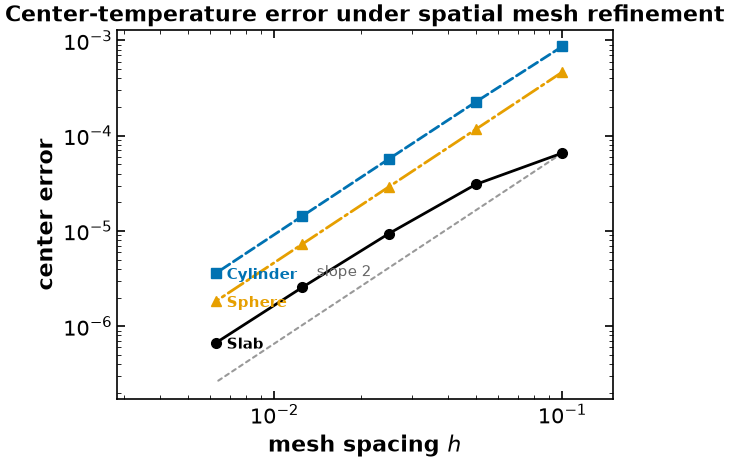

In [9]:
h = 1.0 / np.asarray(results["nfe_r"], dtype=float)

fig, ax = plt.subplots(figsize=(6.4, 4.8))

MARKERS = {0: "o", 1: "s", 2: "^"}
for row in results["geometries"]:
    s = row["shape_index"]
    errors = np.asarray(row["errors"], dtype=float)
    (line,) = ax.loglog(h, errors, marker=MARKERS[s], markersize=7, lw=2.0)
    # direct labelling: a legend keyed only by colour dies in black and white
    ax.annotate(row["geometry"], xy=(h[-1], errors[-1]), xytext=(8, -4),
                textcoords="offset points", fontsize=11,
                color=line.get_color(), fontweight="bold")

# reference slope, drawn in grey so it never competes with the data
slab_errors = np.asarray(results["geometries"][0]["errors"], dtype=float)
ax.loglog(h, slab_errors[0] * (h / h[0]) ** 2, color="0.6", lw=1.5,
          ls=(0, (2, 2)), zorder=0)
ax.annotate("slope 2", xy=(h[2], slab_errors[0] * (h[2] / h[0]) ** 2),
            xytext=(-52, -6), textcoords="offset points", fontsize=11, color="0.4")

ax.set_xlabel("mesh spacing $h$")
ax.set_ylabel("center error")
ax.set_xlim(h[-1] / 2.2, h[0] * 1.5)
ax.set_title("Center-temperature error under spatial mesh refinement")

# Write media/figures/heat-convergence.{png,pdf} -- what the lecture handout
# \includegraphics. A no-op on Colab, where there is no repo to write to.
helper.save_figure(fig, "heat-convergence")
plt.show()


Three straight lines of slope 2, over four mesh halvings and more than two decades of error. That is what a
consistent, correctly posed discretization looks like on a log-log plot, and it is the picture the
dangling model cannot produce on the slab no matter how fine the mesh gets.

### Reproducibility and archived figure data

The two figures printed in Lecture 7 are generated from committed numerical data, not from a
second implementation of this PDE. `figures/results/heat-convergence.json` stores the raw mesh-
refinement errors for **all three geometries**, the initial-guess experiment, and the expected
structural-diagnostics summary. `figures/results/heat-slab-profile.json` stores every profile and
analytical-series comparison for the slab, cylinder, and sphere; the handout uses the slab subset.

A maintainer re-renders either handout figure without Pyomo or IPOPT with:

```bash
python figures/render_from_notebook.py heat-convergence heat-slab-profile
```

The archived runs used Pyomo 6.10.1, IPOPT 3.13.2 (IDAES build with `ma27`), `nfe_t=30`, and
three Radau collocation points for the refinement experiment; the profile data use `nfe_r=80`,
`nfe_t=50`, and three Radau points. Exact iteration counts and timings are intentionally not used
as scientific evidence: they depend on the operating system, solver build, linear solver, and CPU.
The structural claims do not: the degree-of-freedom count, expected diagnostics cautions, initial-
guess invariance, and second-order convergence are the checks to reproduce.

## The Correct Model, Geometry by Geometry

The builder is the same in all three cases. What changes is *why* each piece is correct.

### Slab, $s = 0$

The PDE is $\partial_t T = \partial_r^2 T$ -- no singular term at all. We could legitimately write the
PDE row at $r=0$ and drop the symmetry condition; the slab is only "half" of a symmetric plate of
thickness $2R$, and $r=0$ is its midplane. We do **not**, for two reasons. `scheme="CENTRAL"` supplies
no second-derivative equation at $r=0$ either, so that row would need a one-sided stencil of its own;
and keeping the same skip-plus-symmetry structure for all three geometries means one code path, tested
three ways. So: skip the PDE at $r=0$, impose $\partial_r T|_0 = 0$ **with its defining equation**.

### Cylinder, $s = 1$

Now the skip at $r = 0$ is mandatory: $\frac{1}{r}\partial_r T$ cannot be evaluated there. The symmetry
condition is doing real work -- it is the *only* equation that determines the axis temperature, and
without a defining equation for $\texttt{dTdr}[t,0]$ the axis is unconstrained. Every interior row
$i = 1, \dots, N-1$ has $r_i = i h > 0$, so the $1/r$ coefficient is finite everywhere it is used; it is
large ($1/h$) at the first interior node, which is why the discrete operator is stiff near the axis and
why an $\mathcal{O}(h^2)$ symmetry stencil is worth having.

### Sphere, $s = 2$

Identical structure, with $2/r$. The $1/r$ weighting is stronger, so the near-center rows dominate the
Jacobian even more -- which is also why the dangling model of the first table is *least* visibly wrong
here. Nothing about the correct model changes.

In all three cases the count works out the same way, per time point: $N$ unknowns
$T_0, \dots, T_{N-1}$ (the surface value $T_N$ is imposed), $N-1$ PDE rows at the interior nodes, and
one center row. $N$ equations, $N$ unknowns, zero degrees of freedom -- which is what the DOF table
above confirms.

In [10]:
# Production models: second-order symmetry stencil, fine mesh.
TIMES = [0.01, 0.05, 0.15, 0.5]

profile_rows = []
for s in [0, 1, 2]:
    m = build_fd(s=s, nfe_r=80, tf=max(TIMES), nfe_t=50, ncp=3)
    status = solve_model(m)
    rgrid = np.array(sorted(m.r))
    numeric_profiles = {}
    analytic_profiles = {}
    for tt in TIMES:
        # the collocation mesh contains every element boundary, and TIMES were
        # chosen to land on one; assert rather than silently interpolate
        assert tt in m.t, f"t = {tt} is not a mesh point"
        numeric_profiles[str(tt)] = [pyo.value(m.T[tt, r]) for r in rgrid]
        analytic_profiles[str(tt)] = analytic(s, tt, rgrid).tolist()
    err = max(
        np.max(np.abs(np.asarray(numeric_profiles[str(tt)]) - np.asarray(analytic_profiles[str(tt)])))
        for tt in TIMES if tt >= 0.05
    )
    profile_rows.append({
        "shape_index": s,
        "geometry": GEOMETRY[s],
        "status": str(status),
        "r": rgrid.tolist(),
        "numeric_profiles": numeric_profiles,
        "analytic_profiles": analytic_profiles,
        "max_abs_error_for_fo_ge_0_05": float(err),
    })
    print(f"{GEOMETRY[s]:9s} status = {status},  max |numeric - series| over r for Fo >= 0.05: {err:.2e}")

profile_results = {
    "times": TIMES,
    "nfe_r": 80,
    "nfe_t": 50,
    "ncp": 3,
    "geometries": profile_rows,
}
helper.save_results(
    "heat-slab-profile",
    profile_results,
    notebook="notebooks/3-dev/heat_conduction_pde.ipynb",
    description=(
        "Raw temperature profiles for the slab, cylinder and sphere, calculated "
        "with the shipped finite-difference spatial discretization and Radau "
        "collocation in time. The handout shows the slab subset; this archive retains "
        "all three geometries and the analytical-series comparison."
    ),
    solver="Ipopt 3.13.2 (IDAES build, linear solver ma27); Pyomo 6.10.1",
)
results = profile_results


Slab      status = optimal,  max |numeric - series| over r for Fo >= 0.05: 4.26e-05


Cylinder  status = optimal,  max |numeric - series| over r for Fo >= 0.05: 8.26e-05


Sphere    status = optimal,  max |numeric - series| over r for Fo >= 0.05: 1.34e-04
[helper] wrote figures/results/heat-slab-profile.json


```{note}
The comparison above excludes $\mathrm{Fo} = 0.01$. At very short times the profile is a thin boundary
layer near the surface, and both sides of the comparison struggle: the truncated series converges
slowly, and an 80-element uniform mesh under-resolves the layer. That is a genuine limitation of a
uniform mesh, not a bug -- and a good argument for the graded meshes that finite element and finite
volume codes make easy.
```

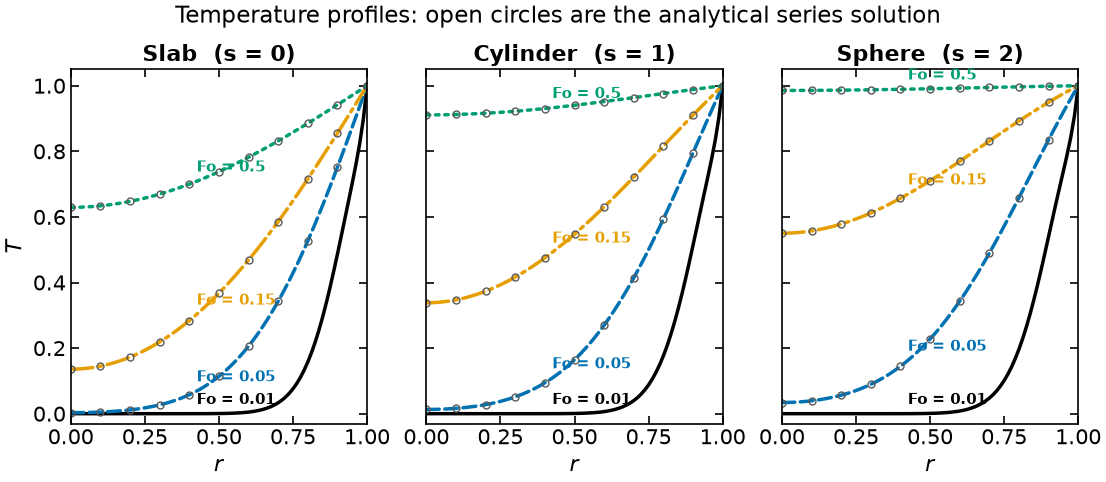

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), sharey=True)

for ax, row in zip(axes, results["geometries"]):
    rgrid = np.asarray(row["r"], dtype=float)
    for tt in results["times"]:
        key = str(tt)
        (line,) = ax.plot(rgrid, row["numeric_profiles"][key], lw=2.5)
        # direct labelling: a legend keyed only by colour dies in black and white
        j = int(0.42 * len(rgrid))
        ax.annotate(f"Fo = {tt:g}", xy=(rgrid[j], row["numeric_profiles"][key][j]),
                    xytext=(0, 7), textcoords="offset points",
                    fontsize=11, color=line.get_color(), fontweight="bold")
    # series solution, as sparse open markers, for the two well-resolved times
    for tt in results["times"][1:]:
        key = str(tt)
        ax.plot(rgrid[::8], np.asarray(row["analytic_profiles"][key])[::8], ls="none", marker="o",
                mfc="none", mec="0.35", ms=5, mew=1.0)
    ax.set_xlabel("$r$")
    ax.set_title(f"{row['geometry']}  (s = {row['shape_index']})")
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.03, 1.05)

axes[0].set_ylabel("$T$")
fig.suptitle("Temperature profiles: open circles are the analytical series solution", y=1.02)
plt.show()


The lecture handout carries the **slab** profile and the convergence plot above.
The slab is the geometry where the dangling-variable defect is loud, so it is the one
worth printing. The cylinder and sphere are on this page only — see the three-panel
figure above.

[helper] wrote media/figures/heat-slab-profile.png and .pdf


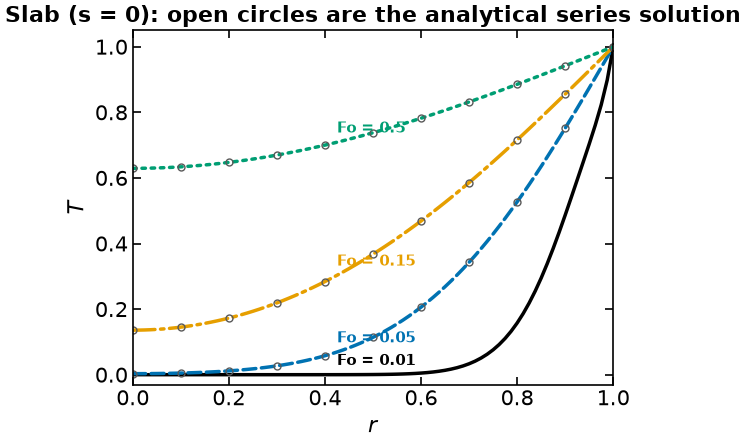

In [12]:
fig, ax = plt.subplots(figsize=(6.2, 4.6))

slab = results["geometries"][0]
rgrid = np.asarray(slab["r"], dtype=float)
for tt in results["times"]:
    key = str(tt)
    (line,) = ax.plot(rgrid, slab["numeric_profiles"][key], lw=2.5)
    j = int(0.42 * len(rgrid))
    ax.annotate(f"Fo = {tt:g}", xy=(rgrid[j], slab["numeric_profiles"][key][j]),
                xytext=(0, 7), textcoords="offset points",
                fontsize=11, color=line.get_color(), fontweight="bold")
for tt in results["times"][1:]:
    key = str(tt)
    ax.plot(rgrid[::8], np.asarray(slab["analytic_profiles"][key])[::8], ls="none", marker="o",
            mfc="none", mec="0.35", ms=5, mew=1.0)
ax.set_xlabel("$r$")
ax.set_ylabel("$T$")
ax.set_title("Slab (s = 0): open circles are the analytical series solution")
ax.set_xlim(0, 1)
ax.set_ylim(-0.03, 1.05)

# Write media/figures/heat-slab-profile.{png,pdf} for the lecture handout.
helper.save_figure(fig, "heat-slab-profile")
plt.show()


At a fixed Fourier number the sphere is furthest along and the slab is furthest behind. That is the
surface-to-volume ratio: per unit volume, a sphere presents $3/R$ of surface, a cylinder $2/R$, a slab
$1/R$. The shape index $s$ is doing exactly that bookkeeping, and it is the reason $\mathrm{Fo}$ alone
is not enough to say "how hot is it inside" without also saying which shape you meant.

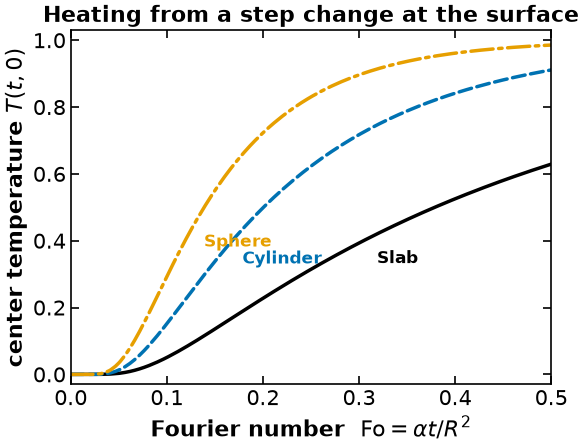

In [13]:
fig, ax = plt.subplots(figsize=(6.2, 4.6))

for s in [0, 1, 2]:
    m = build_fd(s=s, nfe_r=80, tf=0.5, nfe_t=50, ncp=3)
    solve_model(m)
    tgrid = np.array(sorted(m.t))
    Tc = np.array([pyo.value(m.T[t, 0]) for t in tgrid])
    (line,) = ax.plot(tgrid, Tc, lw=2.5)
    frac = {0: 0.62, 1: 0.34, 2: 0.26}[s]  # keep the three labels off each other
    k = int(frac * len(tgrid))
    ax.annotate(GEOMETRY[s], xy=(tgrid[k], Tc[k]), xytext=(6, -18),
                textcoords="offset points", fontsize=12,
                color=line.get_color(), fontweight="bold")

ax.set_xlabel("Fourier number  $\\mathrm{Fo} = \\alpha t / R^2$")
ax.set_ylabel("center temperature $T(t, 0)$")
ax.set_xlim(0, 0.5)
ax.set_ylim(-0.03, 1.03)
ax.set_title("Heating from a step change at the surface")
plt.show()

## The Finite Volume Alternative

Everything above was finite difference. It is worth building the finite volume version of the same
problem, because it makes a structural point that no amount of care with stencils can:

> In the finite volume formulation the symmetry condition at $r = 0$ **is not a boundary condition at
> all.** It is a consequence of the geometry, and there is nothing to forget.

Place $N$ shells with faces at $r_{i+1/2} = (i+1)h$, $h = 1/N$, and unknowns at the cell centers. The
balance on shell $i$ is the discrete form of the integral law from earlier,

$$V_i \frac{dT_i}{dt} = A_{i+1/2}\frac{T_{i+1} - T_i}{h} - A_{i-1/2}\frac{T_i - T_{i-1}}{h},
\qquad A_{i+1/2} = r_{i+1/2}^{\,s}, \quad V_i = \frac{r_{i+1/2}^{\,s+1} - r_{i-1/2}^{\,s+1}}{s+1}.$$

For the innermost shell, $r_{-1/2} = 0$ and therefore $A_{-1/2} = 0^{s} = 0$ for $s > 0$: **the inner
face has no area, so no heat can cross it.** For the slab, $s = 0$ makes $A_{-1/2} = 1$, and we set the
inner flux to zero by symmetry -- one line, and the only geometry-specific line in the model.

At the outer face of the last shell the temperature is known, and the half-cell distance from the
center of that shell to the surface is $h/2$, so the flux is $A_{N-1/2}\,(1 - T_{N-1}) / (h/2)$.

Note also that there is no `DerivativeVar` in space at all. The method of lines is explicit here: the
only `ContinuousSet` is time.

In [14]:
def build_fv(s, ncells, tf=0.5, nfe_t=30, ncp=3):
    """Finite volume discretization of the same problem.

    Shells of equal thickness h = 1/ncells, unknowns at cell centers, fluxes at faces.
    Conservative by construction, and the symmetry condition at r = 0 is structural.
    """
    h = 1.0 / ncells
    faces = np.linspace(0.0, 1.0, ncells + 1)
    centers = 0.5 * (faces[:-1] + faces[1:])
    area = faces**s                                     # A = r^s at each face
    vol = (faces[1:] ** (s + 1) - faces[:-1] ** (s + 1)) / (s + 1)

    m = pyo.ConcreteModel()
    m.t = dae.ContinuousSet(bounds=(0, tf))
    m.c = pyo.RangeSet(0, ncells - 1)                   # cell index; NOT a ContinuousSet
    m.T = pyo.Var(m.t, m.c, initialize=0.0)
    m.dTdt = dae.DerivativeVar(m.T, wrt=m.t)

    @m.Constraint(m.t, m.c)
    def shell(m, t, i):
        if t == 0:
            return pyo.Constraint.Skip
        if i == 0:
            flux_in = 0.0                               # zero face area (s>0) or symmetry (s=0)
        else:
            flux_in = area[i] * (m.T[t, i] - m.T[t, i - 1]) / h
        if i == ncells - 1:
            flux_out = area[i + 1] * (1.0 - m.T[t, i]) / (h / 2)   # bath at r = 1
        else:
            flux_out = area[i + 1] * (m.T[t, i + 1] - m.T[t, i]) / h
        return vol[i] * m.dTdt[t, i] == flux_out - flux_in

    @m.Constraint(m.c)
    def ic(m, i):
        return m.T[0, i] == 0

    pyo.TransformationFactory("dae.collocation").apply_to(
        m, wrt=m.t, nfe=nfe_t, ncp=ncp, scheme="LAGRANGE-RADAU"
    )
    m.obj = pyo.Objective(expr=0.0)
    m.centers = centers
    return m

In [15]:
NC_LIST = [10, 20, 40, 80]
print(f"{'geometry':10s} {'DOF':>5s}   " + "".join(f"{'N='+str(n):>12s}" for n in NC_LIST) + f"{'order':>9s}")
fv_conv = {}
for s in [0, 1, 2]:
    errs = []
    for n in NC_LIST:
        m = build_fv(s=s, ncells=n)
        solve_model(m)
        # compare at the first cell center, r = h/2
        errs.append(abs(pyo.value(m.T[0.5, 0]) - analytic(s, 0.5, m.centers[0])[0]))
    fv_conv[s] = np.array(errs)
    rep = build_model_size_report(build_fv(s=s, ncells=40)).activated
    order = np.log2(errs[-2] / errs[-1])
    print(f"{GEOMETRY[s]:10s} {rep['variables'] - rep['constraints']:5d}   "
          + "".join(f"{v:12.3e}" for v in errs) + f"{order:9.2f}")

geometry     DOF           N=10        N=20        N=40        N=80    order


Slab           0      1.318e-03   3.299e-04   8.251e-05   2.063e-05     2.00


Cylinder       0      9.179e-04   2.294e-04   5.734e-05   1.433e-05     2.00


Sphere         0      3.672e-04   9.172e-05   2.293e-05   5.734e-06     2.00


Zero degrees of freedom in every geometry, second-order convergence, and no symmetry constraint anywhere
in the model. The Diagnostics Toolbox says the same thing structurally.

In [16]:
DiagnosticsToolbox(build_fv(s=1, ncells=8, nfe_t=4)).report_structural_issues()

Model Statistics

        Activated Blocks: 1 (Deactivated: 0)
        Free Variables in Activated Constraints: 200 (External: 0)
            Free Variables with only lower bounds: 0
            Free Variables with only upper bounds: 0
            Free Variables with upper and lower bounds: 0
        Fixed Variables in Activated Constraints: 0 (External: 0)
        Activated Equality Constraints: 200 (Deactivated: 0)
        Activated Inequality Constraints: 0 (Deactivated: 0)
        Activated Objectives: 1 (Deactivated: 0)

------------------------------------------------------------------------------------
0 WARNINGS

    No warnings found!

------------------------------------------------------------------------------------
1 Cautions

    Caution: 8 unused variables (0 fixed)

------------------------------------------------------------------------------------
Suggested next steps:

    Try to initialize/solve your model and then call report_numerical_issues()



Zero warnings again, and this time a single caution: the 8 unused variables are $\texttt{dTdt}$ at
$t = 0$, one per cell, which Radau collocation never references. There is no *"fixed to 0"* caution,
because there is nothing to fix -- and that is the argument for finite volume in one line. Not that it
is more accurate (on this uniform mesh it is not dramatically so), but that the condition we spent the
first half of this notebook getting right **cannot be gotten wrong**: the inner face of the first shell
has zero area, so no heat can cross it, structurally and on every mesh.

The price is that a finite volume model is *yours to write*. `Pyomo.dae` will not build it for you,
you do not get a `DerivativeVar` to inspect, and the cell-center unknowns do not sit on the boundary,
so reporting a surface value takes an extra half-cell extrapolation. Which is the right trade depends
on the problem, and that is the point of knowing all three families.

The mistakes move with the method. Finite volume cannot lose the symmetry condition, but it has its own
short list -- and, symmetrically with the first table, its worst failure is the one the *slab* cannot see.

### Alternative Finite Volume Discretizations, and What They Do

Same convention as the first table: these were measured, not reasoned about, and none of them ships as
a runnable option above. Conditions are $\mathrm{Fo} = t_f = 0.5$, `nfe_t=30`, `ncp=3` Radau, IPOPT
3.13.2 with `ma27`, and $N = 10,\, 20,\, 40,\, 80$ cells. The error is taken at the first cell center,
$r = h/2$, against the series solution evaluated there; "order" is $\log_2$ of the ratio of the last two.

| Alternative discretization | Modeling issue | Failure evidence (measured) |
| :-- | :-- | :-- |
| **Evaluate the face areas at the cell center**, $A_{i\pm1/2} \to r_i^{\,s}$, instead of at the faces | **Not conservative.** The flux leaving cell $i$ is no longer identically the flux entering cell $i+1$, so the sum over cells stops telescoping -- the one property finite volume exists to provide. For $s>0$ it is not even consistent. | Slab **unaffected** ($A \equiv 1$ either way, so the bug is invisible at $s=0$). Cylinder error **plateaus** at 0.2824, 0.2820, 0.2819, 0.2819 -- observed **order 0.00**. Sphere 0.3890, 0.3738, 0.3654, 0.3610 -- observed **order 0.02**. Every solve returned `optimal`. 🔴 The mirror image of the finite difference trap: **loud on the cylinder and sphere, silent on the slab.** |
| **Lumped cell volume** $V_i \approx A_{i+1/2}\,h$ instead of the exact shell volume $\frac{r_{i+1/2}^{\,s+1} - r_{i-1/2}^{\,s+1}}{s+1}$ | **First-order mass matrix.** The volume multiplies $dT_i/dt$; approximating it to $\mathcal{O}(h)$ degrades the whole scheme even though it stays conservative, square and stable. Tempting because it is one fewer line. | Slab unaffected (the volume is exact there). Cylinder 5.22e-2, 2.53e-2, 1.24e-2, 6.14e-3 -- observed **order 1.02**. Sphere 2.99e-2, 1.20e-2, 5.33e-3, 2.50e-3 -- observed **order 1.09**. Against **order 2.00** for the shipped model. |
| **Outer boundary flux over the full cell width** $h$ instead of the half cell $h/2$ | **Wrong distance at the Dirichlet face.** The last unknown sits at a cell *center*, a distance $h/2$ from the surface. Using $h$ halves the surface flux and makes a first-order boundary error the accuracy bottleneck -- the finite volume version of an under-resolved boundary row. | Order falls to **1.00 in all three geometries**: slab 4.51e-2 $\to$ 5.71e-3, cylinder 2.83e-2 $\to$ 3.26e-3, sphere 9.04e-3 $\to$ 9.15e-4 over $N = 10 \to 80$. |
| **Node-centered layout with an explicit symmetry boundary condition at $r=0$** (i.e. put an unknown *on* the axis) | Reintroduces the Neumann condition that cell-centered finite volume removes -- and with it the dangling-variable failure mode in full. | See the finite difference table above; this *is* that table. |
| ✅ **Shipped: cell-centered, face areas at the faces, exact shell volumes, half-cell surface flux** | Conservative by construction; the symmetry condition is structural, not written. | **DOF = 0** in all three geometries, **0 warnings** from `report_structural_issues()`, observed **order 2.00** everywhere, and **no symmetry constraint anywhere in the model**. |

## Take-Home Messages

1. **Nondimensionalize first.** Three geometries, any material, any size and any temperature pair reduce
   to one equation in one parameter $s$, with the Fourier number as the clock.
2. **The method of lines is a decision, not a syntax.** Discretizing space first is what lets you hand
   the time direction to Lecture 7's collocation machinery and concentrate on the spatial operator,
   where the physics lives.
3. **Finite difference, finite volume and finite element differ in what they reproduce exactly** --
   the Taylor series, the integral balance, or a weighted residual. Reach for FV when conservation or
   an interface matters, FE when the geometry or the accuracy demands it, FD when neither does.
4. 🔴 **A Neumann boundary condition written on a `DerivativeVar` may constrain nothing.** `CENTRAL`
   finite differences and Radau collocation both leave the derivative at the left endpoint of the domain
   with **no defining equation**. Writing `m.dTdr[t, 0] == 0` and stopping there assigns a value to a
   dangling variable, and the center temperature is unconstrained. Write the defining equation too.
5. **`optimal` is not `correct`.** Every failure in the two tables above terminated cleanly, several of
   them with plausible-looking numbers. Three things catch this class of defect: a **degree-of-freedom
   count** -- a simulation must have zero -- **`report_structural_issues()`**, which says *which*
   variables are loose rather than how many, and **mesh refinement**, which turns a structural defect
   into a visible plateau. Do all three.
6. **Run the diagnostics before you run the solver.** `report_structural_issues()` needs no solution and
   no initialization; it costs seconds and it reads the incidence pattern you cannot read by eye. Learn
   what cautions your model *should* emit, so that a new one means something.
7. **Test on the geometry where the bug is loud.** The finite difference defect was obvious in the slab
   and nearly invisible in the sphere; the finite volume defect is the other way round. A model verified
   only on the forgiving case is not verified.

## Try It Yourself

1. Predict, before running it, which endpoint loses its defining equation under `scheme="BACKWARD"` and
   what that breaks in `build_fd`. Check your answer with `stencil_coverage("BACKWARD")` -- and then say
   what one-sided row you would owe the model to repair it.
2. Replace `dae.finite_difference` in space with `dae.collocation` in a copy of `build_fd` and confirm,
   with the toolbox rather than by eye, that the derivative at $r=0$ still needs a defining equation of
   your own.
3. Add a Robin (convective) boundary condition at the surface, $-\partial_r T|_{r=1} = \mathrm{Bi}\,(T(t,1) - 1)$,
   where $\mathrm{Bi} = hR/k$ is the Biot number. Which endpoint does `CENTRAL` leave undefined now, and
   what does that imply about which one-sided stencil you owe the model? Recover the results above as
   $\mathrm{Bi} \to \infty$.
4. Grade the mesh toward $r=1$ so the short-time boundary layer is resolved, and redo the
   $\mathrm{Fo}=0.01$ comparison. `ContinuousSet(initialize=[...])` accepts an explicit list of points.
5. Reproduce one row of either table for yourself in a scratch copy of the builder -- then delete it.
   Confirming a documented failure mode is worth an hour; leaving a runnable broken model in a notebook
   someone else will copy is not.